# Laboratorio 2 - AlpesPlanck: Regresión Polinomial y Regularizada para predicción de temperatura máxima

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn import set_config
set_config(display="diagram")

pd.set_option('display.max_colwidth', None)

from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import GridSearchCV, KFold, validation_curve
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt

## Carga de los datos

In [2]:
datos_laboratorio = pd.read_csv('./data/Datos Lab 1.csv')
data = datos_laboratorio.copy()

diccionario = pd.read_excel('./data/Diccionario de datos.xlsx')
data.shape

(2576, 27)

# Exploración de los datos

Clasificamos primero las variables según su naturaleza estadística, y luego
exploramos el dataset con `pandas` para identificar problemas de calidad.

In [3]:
cuantitativas_continuas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'temp_max_manana',
]

cuantitativas_discretas = [
    'registros_del_dia',
    'anio',
    'dia_del_anio'
]

cualitativas_nominales = [
    'estacion_anio',
    'mes',
    'sector_viento',
    'fecha'
]

cualitativas_ordinales = []

### Exploración general

A continuación se ejecutan las  exploraciones iniciales sobre el
dataset, para identificar el porcentaje de datos nulos por variable,
ver consistencia de variables categóricas, ver datos repetidos y la validez de dstos.

In [4]:
print(data.describe(include='object'))

             fecha estacion_anio   mes sector_viento
count         2504          2488  2488          2505
unique        2486            28    61            33
top     2009-01-22     primavera   May            SO
freq             2           517   127           695


/var/folders/y0/t7nj_jvx3bb5463r_wtqfj6m0000gn/T/ipykernel_46944/1444247214.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))


**Revisar porcentaje de nulidad por variable**

In [5]:
print(((data.isnull().sum() / data.shape[0])).sort_values(ascending=False))

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64


**Revisar filas duplicadas**

In [6]:
print(int(data.duplicated(keep=False).sum()))
duplicados = datos_laboratorio[datos_laboratorio.duplicated()]
print(duplicados)

8
           fecha  presion_media  presion_min  presion_max  presion_desv  \
2556  2013-04-20      1000.4455       998.46      1002.49        1.1632   
2559  2012-11-13      1005.3724      1002.77      1006.81        1.0690   
2563  2009-01-22      9784.1150       971.48       983.54        3.9853   
2565  2013-02-08       984.6369       983.06       987.49        1.3454   

      humedad_media  humedad_min  humedad_max  humedad_desv  viento_media  \
2556      60.748100        45.71         82.0       10.9518      17.65908   
2559      88.175500        58.28         99.1       12.6853       4.07916   
2563      86.731100        69.11         97.6        9.7926      10.09692   
2565       0.886056         0.76         96.8        4.6160           NaN   

      ...  viento_norte  viento_este  direccion_viento  registros_del_dia  \
2556  ...        4.1573       2.5121           31.1426              144.0   
2559  ...       -0.9230      -0.2193          193.3681              144.0   
2563 

**Revisar consistencia de variable sector_viento**

In [7]:
print(data['sector_viento'].value_counts())

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64


**Revisar consistencia de variable mes**

In [8]:
print(data['mes'].value_counts())

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64


**Revisar consistencia de variable estacion_anio**

In [9]:
print(data['estacion_anio'].value_counts())

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64


**Revisar validez de variables con rangos, usando mínimos y máximos**

In [10]:
print(data.describe())

       presion_media  presion_min  presion_max  presion_desv  humedad_media  \
count    2501.000000  2502.000000  2512.000000   2496.000000    2502.000000   
mean     1010.494271   986.684409   991.704244      1.752041      52.413586   
std       435.334494     8.927138     7.726906      1.215931      35.975384   
min       948.996000   913.600000   951.940000      0.226900       0.004663   
25%       984.287800   981.371333   987.070000      0.899050       0.869060   
50%       989.452800   987.070000   991.935000      1.444550      68.558100   
75%       994.469000   992.567500   996.782500      2.254800      80.562600   
max      9939.918000  1012.320198  1013.940000     12.397500     100.000000   

       humedad_min  humedad_max  humedad_desv  viento_media   viento_min  ...  \
count  2496.000000  2490.000000   2515.000000   2490.000000  2485.000000  ...   
mean     45.094067    90.236582     10.606821      3.814103     1.417799  ...   
std      30.196163    10.647237      5.481338

### Evidencia de problemas de **validez** (rangos incorrectos)

Un valor es inválido cuando, aunque esté presente (no es nulo), **no tiene sentido
físico** para lo que representa: una humedad relativa no puede superar el 100%,
una presión atmosférica no puede ser 10 veces el máximo histórico registrado en la
Tierra, una desviación estándar no puede ser negativa, etc. A continuación se
contrasta el mínimo y el máximo real de cada variable contra el rango físicamente
válido (según el diccionario de datos y la naturaleza del fenómeno).

In [11]:
rangos_validos = {
    'presion_media': (900, 1085),
    'presion_min': (900, 1085),
    'presion_max': (900, 1085),
    'presion_desv': (0, 50),
    'humedad_media': (0, 100),
    'humedad_min': (0, 100),
    'humedad_max': (0, 100),
    'humedad_desv': (0, 100),
    'viento_media': (0, 60),
    'viento_min': (0, 60),
    'viento_max': (0, 60),
    'viento_desv': (0, 60),
    'rafaga_media': (0, 100),
    'rafaga_min': (0, 100),
    'rafaga_max': (0, 100),
    'rafaga_desv': (0, 100),
    'viento_norte': (-60, 60),
    'viento_este': (-60, 60),
    'direccion_viento': (0, 360),     # dic: "de 0 a 360 grados"
    'registros_del_dia': (0, 144),    # dic: "un dia completo tiene 144"
    'anio': (2003, 2015),             # la estacion mide desde 2003
    'dia_del_anio': (1, 366),         # dic: "de 1 a 366"
}

print(f'{"variable":18s} {"min_real":>12s} {"max_real":>12s}  dentro_rango?')
for var, (lo, hi) in rangos_validos.items():
    mn, mx = data[var].min(), data[var].max()
    dentro = (mn >= lo) and (mx <= hi)
    marca = '' if dentro else '  <-- FUERA DE RANGO (problema de validez)'
    print(f'{var:18s} {mn:12.3f} {mx:12.3f}  {str(dentro):>12s}{marca}')

variable               min_real     max_real  dentro_rango?
presion_media           948.996     9939.918         False  <-- FUERA DE RANGO (problema de validez)
presion_min             913.600     1012.320          True
presion_max             951.940     1013.940          True
presion_desv              0.227       12.398          True
humedad_media             0.005      100.000          True
humedad_min               0.238      103.311         False  <-- FUERA DE RANGO (problema de validez)
humedad_max              27.020      100.000          True
humedad_desv              0.000       26.342          True
viento_media              0.000       24.754          True
viento_min                0.000       45.185          True
viento_max                0.000       45.108          True
viento_desv               0.000     3319.030         False  <-- FUERA DE RANGO (problema de validez)
rafaga_media          -1386.273       11.465         False  <-- FUERA DE RANGO (problema de validez)
rafag

**Hallazgo:** `presion_media`, `humedad_min`, `viento_desv`, `rafaga_media`,
`rafaga_min`, `rafaga_desv`, `viento_norte` y `registros_del_dia` tienen valores
que violan su rango físicamente válido (por ejemplo, `rafaga_min` llega a **-9999**,
un valor típico de sensor/registro fallido; `presion_media` llega a
**~9939 mbar**, unas 10 veces la presión atmosférica máxima físicamente posible).
Esto **no** es un problema de completitud (los datos están presentes, no son
nulos): es un problema de **validez** — el dato existe, pero es incorrecto o no
tiene sentido para la variable que representa.

### Evidencia de problemas de **consistencia** (formato de categóricas)

Ya se observó en el punto 1.1 (`value_counts`) que `estacion_anio`, `mes` y
`sector_viento` tienen la misma información representada de formas distintas:
mayúsculas/minúsculas, texto en inglés, tildes, abreviaturas y errores de
digitación. Esto es un problema de **consistencia**: la variable debería tener un
único formato válido (el que define el diccionario de datos), y en cambio la
misma categoría aparece bajo múltiples representaciones.

In [12]:
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f'--- {col}: {data[col].nunique()} valores unicos encontrados ---')
    print(sorted(data[col].dropna().unique().tolist()))
    print()

--- estacion_anio: 28 valores unicos encontrados ---
['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall', 'invernio', 'invierno', 'invierno ', 'otono', 'otoño ', 'primav', 'primavera', 'primaveraa', 'spring', 'summer', 'verano', 'verno', 'winter']

--- mes: 61 valores unicos encontrados ---
['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY', 'JUNE', 'Jan', 'January', 'Jul', 'July', 'Jun', 'June', 'MARCH', 'MAY', 'Mar', 'March', 'May', 'NOVEMBER', 'Nov', 'November', 'OCTOBER', 'Oct', 'October', 'SEPTEMBER', 'Sep', 'Sept', 'September', 'abril', 'agosto', 'april', 'august', 'december', 'diciembre', 'enero', 'febrero', 'february', 'january', 'julio', 'july', 'june', 'junio', 'march', 'marzo', 'may', 'mayo', 'november', 'noviembre', 'october', 'octubre', 'september', 'septiemb

**Hallazgo:** por ejemplo `estacion_anio` tiene *primavera*, *Primavera*,
*PRIMAVERA*, *primav*, *primaveraa* y *spring* —seis representaciones de la
misma categoría—, además de valores inválidos como `East` o
`Estacion_Desconocida` que no corresponden a ninguna estación del año.

### Evidencia de problemas de **completitud** (valores nulos)

Ya se observó en el punto 1.1 el porcentaje de nulos por columna. La variable
objetivo `temp_max_manana` también tiene nulos, así como varias variables
predictoras. Este es un problema de **completitud**: el dato simplemente no fue
registrado.

### Resumen de hallazgos y dimensiones de calidad de datos

| Dimensión | Problema encontrado | Variables afectadas |
|---|---|---|
| **Validez** | Valores presentes pero fuera del rango físicamente posible (incl. un valor centinela `-9999`) | `presion_media`, `humedad_min`, `viento_desv`, `rafaga_media`, `rafaga_min`, `rafaga_desv`, `viento_norte`, `registros_del_dia` |
| **Consistencia** | La misma categoría representada en múltiples formatos (mayúsculas, inglés, tildes, typos) | `estacion_anio`, `mes`, `sector_viento` |
| **Completitud** | Valores nulos | Prácticamente todas las columnas, incluida la variable objetivo `temp_max_manana` |
| **unicidad** | Valores duplicados | 4 filas duplicadas |

En la sección 2 (Preparación de datos) se define, para cada dimensión, la
estrategia de corrección y su justificación.

# Preparación de datos

Cada corrección se diseña según la dimensión de calidad de datos a la que
responde:

- **Validez** → los valores fuera de rango se corrigen según el tipo de error
  específico de cada variable (recorte al límite, valor absoluto, o marcarlo como
  error para reemplazarlo más adelante).
- **Consistencia** → las categóricas se normalizan (sin tildes, en minúsculas) y
  se mapean al formato exacto que exige el diccionario de datos.
- **Completitud** → los valores nulos se imputan: en variables **categóricas**
  con la **moda**; en variables **cuantitativas**, con la **media** si la
  variable está dentro de su rango normal, o con la **mediana** si tiene valores
  fuera de rango (la mediana es más robusta ante esa contaminación).
- **Unicidad** → Las filas dupicadas se eiminan dejando una sola versión

> **Nota metodológica (fuga de datos):** estas funciones se **definen** aquí,
> pero no se aplican todavía sobre todo el dataset. La normalización de
> categóricas y la corrección de rangos no dependen de ningún estadístico
> calculado sobre los datos (son reglas fijas), así que son seguras de aplicar
> en cualquier momento; pero la **imputación de nulos sí es un estadístico**
> (media/mediana/moda), por lo que debe calcularse **únicamente con el
> conjunto de entrenamiento**. Por eso la imputación se implementa con
> `SimpleImputer`.

### Corrección de consistencia (formato de categóricas)

In [13]:
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def normalizar_texto(valor):
    return quitar_tildes(str(valor).strip().lower())

mapa_estacion_anio = {
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera', 'spring': 'primavera',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'otono': 'otoño', 'fall': 'otoño', 'autumn': 'otoño',
}

mapa_mes = {
    'january': 'enero', 'jan': 'enero', 'enero': 'enero',
    'february': 'febrero', 'feb': 'febrero', 'febrero': 'febrero',
    'march': 'marzo', 'mar': 'marzo', 'marzo': 'marzo',
    'april': 'abril', 'apr': 'abril', 'abril': 'abril',
    'may': 'mayo', 'mayo': 'mayo',
    'june': 'junio', 'jun': 'junio', 'junio': 'junio',
    'july': 'julio', 'jul': 'julio', 'julio': 'julio',
    'august': 'agosto', 'aug': 'agosto', 'agosto': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre', 'septiembre': 'septiembre',
    'october': 'octubre', 'oct': 'octubre', 'octubre': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre', 'noviembre': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre', 'diciembre': 'diciembre',
}

mapa_sector_viento = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'e': 'E', 'east': 'E', 'este': 'E',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    's': 'S', 'south': 'S', 'sur': 'S',
    'so': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
    'o': 'O', 'west': 'O', 'oeste': 'O',
    'no': 'NO', 'northwest': 'NO', 'noroeste': 'NO',
}

def normalizar_categoricas(df):
    # Consistencia: cada categoria se lleva al unico formato valido del diccionario.
    df = df.copy()
    df['estacion_anio'] = df['estacion_anio'].apply(
        lambda x: mapa_estacion_anio.get(normalizar_texto(x)) if pd.notna(x) else x)
    df['mes'] = df['mes'].apply(
        lambda x: mapa_mes.get(normalizar_texto(x)) if pd.notna(x) else x)
    df['sector_viento'] = df['sector_viento'].apply(
        lambda x: mapa_sector_viento.get(normalizar_texto(x)) if pd.notna(x) else x)
    return df

corrector_categoricas = FunctionTransformer(normalizar_categoricas)

### Corrección de validez (valores fuera de rango)

La estrategia se elige según el patrón de error específico de cada variable
(ver el diagnóstico detallado hecho previamente sobre este mismo dataset):

| Variable | Patrón encontrado | Estrategia |
|---|---|---|
| `presion_media` | Valores ~10x el real, sin patrón limpio de digito repetido | Error -> se marca NaN (se completa por completitud en el pipeline) |
| `humedad_min` | Apenas supera el 100% | Recorte al límite (`clip`) |
| `viento_desv` | Un extremo aislado (~10x el resto) + valores moderadamente fuera de rango | Extremo -> NaN; resto -> `clip` |
| `rafaga_media` | Un valor extremo negativo | Error -> NaN |
| `rafaga_min` | Valor centinela `-9999` | Error -> NaN |
| `rafaga_desv` | Muchos valores negativos (una desviación estándar nunca es negativa) | Signo -> `abs()`, luego `clip` |
| `viento_norte` | Un valor extremo aislado | Error -> NaN |
| `registros_del_dia` | Supera el máximo físico de 144 registros/día | Recorte al límite (`clip`) |

In [14]:
def corregir_rangos_numericos(df):
    df = df.copy()

    # presion_media: atipico = error de validez -> NaN
    lo, hi = rangos_validos['presion_media']
    fuera = (df['presion_media'] < lo) | (df['presion_media'] > hi)
    df.loc[fuera, 'presion_media'] = np.nan

    # humedad_min: fuera de rango leve -> clip
    lo, hi = rangos_validos['humedad_min']
    df['humedad_min'] = df['humedad_min'].clip(lower=lo, upper=hi)

    # viento_desv: extremo aislado (>1000) = error -> NaN; resto -> clip
    df.loc[df['viento_desv'] > 1000, 'viento_desv'] = np.nan
    lo, hi = rangos_validos['viento_desv']
    df['viento_desv'] = df['viento_desv'].clip(lower=lo, upper=hi)

    # rafaga_media: atipico = error -> NaN
    lo, hi = rangos_validos['rafaga_media']
    fuera = (df['rafaga_media'] < lo) | (df['rafaga_media'] > hi)
    df.loc[fuera, 'rafaga_media'] = np.nan

    # rafaga_min: -9999 (centinela) = error -> NaN
    lo, hi = rangos_validos['rafaga_min']
    fuera = (df['rafaga_min'] < lo) | (df['rafaga_min'] > hi)
    df.loc[fuera, 'rafaga_min'] = np.nan

    # rafaga_desv: negativo deberia ser positivo -> abs(), luego clip
    df['rafaga_desv'] = df['rafaga_desv'].abs()
    lo, hi = rangos_validos['rafaga_desv']
    df['rafaga_desv'] = df['rafaga_desv'].clip(lower=lo, upper=hi)

    # viento_norte: atipico = error -> NaN
    lo, hi = rangos_validos['viento_norte']
    fuera = (df['viento_norte'] < lo) | (df['viento_norte'] > hi)
    df.loc[fuera, 'viento_norte'] = np.nan

    # registros_del_dia: fuera de rango -> clip
    lo, hi = rangos_validos['registros_del_dia']
    df['registros_del_dia'] = df['registros_del_dia'].clip(lower=lo, upper=hi)

    return df

corrector_rangos = FunctionTransformer(corregir_rangos_numericos)

### Corrección de completitud (imputación de nulos)

**Regla:** en las variables cuantitativas, se imputa con la **media** si la
variable se encuentra dentro de su rango normal, y con la **mediana** si tiene
valores fuera de rango (dato contaminado por atípicos). Como en el paso 2.2 ya se
corrigieron todos los valores fuera de rango, **todas** las variables numéricas
quedan dentro de su rango válido — por lo tanto, todas califican para
imputación con **media**. En las variables categóricas nominales/ordinales, los
nulos se imputan con la **moda**.

Esta imputación se implementa con `SimpleImputer` dentro del `Pipeline` de
modelado (sección 3), ajustado **solo con el conjunto de entrenamiento**, para
no incurrir en fuga de datos.

### Corrección de Unicidad 

Se eliminan las filas duplicadas del set de datos, antes de separar los datos de entrenamiento y crear el pipeline.

In [15]:
data = data.drop_duplicates().reset_index(drop=True)
print(int(data.duplicated(keep=False).sum()))

0


### Eliminación de columnas no predictoras y del target nulo

`fecha` es un identificador (ya está descompuesta en `anio`, `mes`,
`dia_del_anio`, `estacion_anio`), así que se elimina como variable predictora.
La variable objetivo `temp_max_manana` **no se imputa** (imputar una etiqueta
sería inventar el dato que se quiere predecir); en su lugar se eliminan las filas
donde es nula, antes de dividir en train/test. Esta es una operación que no usa
ningún estadístico calculado sobre los datos, por lo que es segura de aplicar
antes del split.

In [16]:
cols_to_drop = ['fecha']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore')

dropper = FunctionTransformer(drop_columns)

In [17]:
n_antes = data.shape[0]
data = data.dropna(subset=['temp_max_manana']).reset_index(drop=True)
print(f'Filas eliminadas por temp_max_manana nula: {n_antes - data.shape[0]}')
print(f'Filas restantes: {data.shape[0]}')

Filas eliminadas por temp_max_manana nula: 95
Filas restantes: 2477


### Partición train / test

Se usa la semilla y proporción indicadas en las consideraciones del laboratorio: `random_state=42`, `test_size=0.25`.

In [18]:
target = 'temp_max_manana'
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((1857, 26), (620, 26))

# Actividad 1. Regresión polinomial

Se construye un pipeline que agrega la generación de características
polinomiales sobre las variables numéricas (después de la imputación y el
escalamiento). Se reutilizan las correcciones de **validez**,
**consistencia** y la eliminación (`dropper`) ya definidas en la sección de preparación.

**Estrategia de preparación:** se usan todas las variables disponibles. Las
numéricas se imputan con la media y luego se escalan — el tipo de escalador
(`StandardScaler` vs `MinMaxScaler`) se deja como **hiperparámetro** a buscar,
igual que el grado del polinomio. Las categóricas se imputan con la moda y se
codifican con One-Hot.

In [19]:
numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio', 'dia_del_anio',
]

categorical_features = ['estacion_anio', 'mes', 'sector_viento']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
])

In [20]:
numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2)),
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline_polinomial = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_poly),
    ('modelo', LinearRegression()),
])

pipeline_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_categoricas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x11c9cd580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

### Búsqueda de hiperparámetros con `GridSearchCV`

Se explora el **grado del polinomio** (1, 2 y 3) y la **estrategia de
escalamiento** (`StandardScaler` vs `MinMaxScaler`). Se usa validación cruzada
con `cv=5` y `neg_root_mean_squared_error` como métrica de selección al obtener el RMSE real.

In [21]:
param_grid_poly = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
}

grid_polinomial = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

In [22]:
%%time
grid_polinomial.fit(X_train, y_train)

CPU times: user 616 ms, sys: 326 ms, total: 942 ms
Wall time: 34.7 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for c

In [23]:
print('Mejor configuracion:', grid_polinomial.best_params_)
print(f'Mejor RMSE promedio en GridSearchCV: {-grid_polinomial.best_score_:.4f}')

Mejor configuracion: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE promedio en GridSearchCV: 7.0106


### Evaluación del mejor modelo polinomial

In [24]:
mejor_polinomial = grid_polinomial.best_estimator_

y_train_pred_poly = mejor_polinomial.predict(X_train)
y_test_pred_poly = mejor_polinomial.predict(X_test)

rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))
mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)
r2_train_poly = r2_score(y_train, y_train_pred_poly)

rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print('Modelo de regresion polinomial (mejor configuracion)')
print(f'Train -> RMSE: {rmse_train_poly:.4f} | MAE: {mae_train_poly:.4f} | R2: {r2_train_poly:.4f}')
print(f'Test  -> RMSE: {rmse_test_poly:.4f} | MAE: {mae_test_poly:.4f} | R2: {r2_test_poly:.4f}')

Modelo de regresion polinomial (mejor configuracion)
Train -> RMSE: 6.7379 | MAE: 5.1498 | R2: 0.4653
Test  -> RMSE: 6.7717 | MAE: 5.2562 | R2: 0.4645


### Análisis de resultados

Comparando los valores del RMSE/MAE/R2 del modelo de entrenamiento con los del modelo de prueba, se puede contemplar que son casi ídenticos, lo que quiere decir que no hay un sobreajuste con el modelo de entrenamiento, y por ende la selección del polinomio (de grado 1) y del escalador fueron las mejores opciones.

# Actividad 2. Curvas de validación

Se usa `validation_curve` para observar cómo cambia el error RMSE, tanto en
entrenamiento como en validación cruzada, a medida que aumenta el grado del
polinomio. Esto permite visualizar el punto en el que el modelo empieza un
sobreajuste, donde el error de entrenamiento sigue bajando, pero el de validación
sube o se estanca.

Se fija el escalador en `StandardScaler` (el que ganó la búsqueda de la
Actividad 1) para aislar el efecto del grado del polinomio.

In [25]:
pipeline_curva = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_poly),
    ('modelo', LinearRegression()),
])

rango_grados = [1, 2, 3, 4]

train_scores, cv_scores = validation_curve(
    estimator=pipeline_curva,
    X=X_train, y=y_train,
    param_name='preprocesamiento__num__polynomial__degree',
    param_range=rango_grados,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

rmse_train_curva = -train_scores
rmse_cv_curva = -cv_scores

rmse_train_mean = rmse_train_curva.mean(axis=1)
rmse_train_std = rmse_train_curva.std(axis=1)
rmse_cv_mean = rmse_cv_curva.mean(axis=1)
rmse_cv_std = rmse_cv_curva.std(axis=1)

for g, tr_m, tr_s, cv_m, cv_s in zip(rango_grados, rmse_train_mean, rmse_train_std, rmse_cv_mean, rmse_cv_std):
    print(f'Grado {g}: RMSE train = {tr_m:.4f} (+/-{tr_s:.4f})  |  RMSE CV = {cv_m:.4f} (+/-{cv_s:.4f})')

Grado 1: RMSE train = 6.7074 (+/-0.0660)  |  RMSE CV = 7.0106 (+/-0.2802)
Grado 2: RMSE train = 4.2322 (+/-0.0428)  |  RMSE CV = 43.2204 (+/-63.2481)
Grado 3: RMSE train = 0.0130 (+/-0.0077)  |  RMSE CV = 388.8129 (+/-442.4821)
Grado 4: RMSE train = 0.0808 (+/-0.1103)  |  RMSE CV = 153.3037 (+/-209.4307)


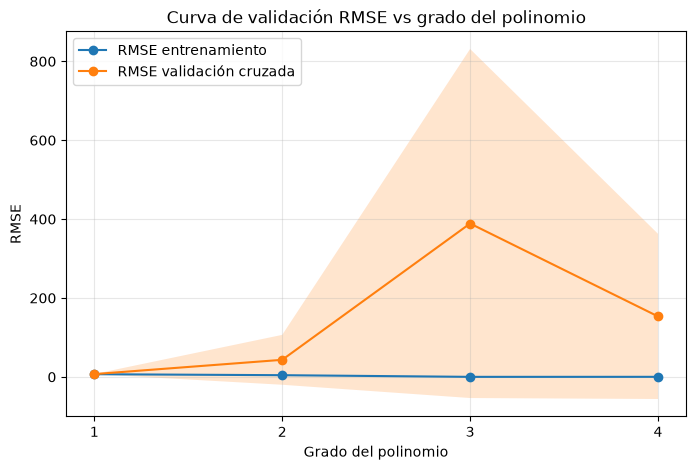

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(rango_grados, rmse_train_mean, marker='o', label='RMSE entrenamiento')
plt.fill_between(rango_grados,
                  rmse_train_mean - rmse_train_std,
                  rmse_train_mean + rmse_train_std,
                  alpha=0.2)

plt.plot(rango_grados, rmse_cv_mean, marker='o', label='RMSE validación cruzada')
plt.fill_between(rango_grados,
                  rmse_cv_mean - rmse_cv_std,
                  rmse_cv_mean + rmse_cv_std,
                  alpha=0.2)

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validación RMSE vs grado del polinomio')
plt.xticks(rango_grados)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Análisis de resultados

En la gráfica se puede evidenciar que los primeros dos grados de polinomio, aunque para el segundo grado el RMSE crece bastante, hay un buen ajuste del modelo, sobretodo para el grado 1 o lineal. Sin embargo, el punto de sobreajuste se evidencia apartir del grado 3 del polinomio, donde el RMSE del entrenamiento baja pero el RMSE de prueba se dispara a 388, evidencia un claro sobreajuste donde el modelo solo opera bien para los datos de entrenamiento, aunque en el grado 4 el RMSE de prueba baje un poco, sigue habiendo un sobreajuste más que evidente. Esto se debe principalmente a la alta varianza en estos polinomios, pues las curvas están tan ajustadas a los datos de prueba que a la mínima variación de estos, el resultado cambia de forma agresiva.

# Actividad 3. Regresión lineal regularizada (Ridge y Lasso)

Se construyen pipelines de regresión regularizada sin características
polinomiales (para aislar el efecto de la penalización), reutilizando las
mismas correcciones de validez y consistencia. El parámetro de penalización
(`alpha`) y la estrategia de escalamiento se buscan con GridSearchCV.

In [27]:
numeric_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer_reg, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

### 3.1 Modelo sin regularización (referencia)

Se entrena un modelo de regresión lineal simple, con la misma preparación de datos, como punto de referencia para comparar el efecto de la regularización.

In [28]:
pipeline_sin_regularizacion = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_reg),
    ('modelo', LinearRegression()),
])

pipeline_sin_regularizacion.fit(X_train, y_train)

y_train_pred_sr = pipeline_sin_regularizacion.predict(X_train)
y_test_pred_sr = pipeline_sin_regularizacion.predict(X_test)

rmse_train_sr = np.sqrt(mean_squared_error(y_train, y_train_pred_sr))
mae_train_sr = mean_absolute_error(y_train, y_train_pred_sr)
r2_train_sr = r2_score(y_train, y_train_pred_sr)

rmse_test_sr = np.sqrt(mean_squared_error(y_test, y_test_pred_sr))
mae_test_sr = mean_absolute_error(y_test, y_test_pred_sr)
r2_test_sr = r2_score(y_test, y_test_pred_sr)

print('Modelo sin regularizacion')
print(f'Train -> RMSE: {rmse_train_sr:.4f} | MAE: {mae_train_sr:.4f} | R2: {r2_train_sr:.4f}')
print(f'Test  -> RMSE: {rmse_test_sr:.4f} | MAE: {mae_test_sr:.4f} | R2: {r2_test_sr:.4f}')

Modelo sin regularizacion
Train -> RMSE: 6.7379 | MAE: 5.1498 | R2: 0.4653
Test  -> RMSE: 6.7717 | MAE: 5.2562 | R2: 0.4645


### 3.2 Modelo Ridge (regularización L2)

In [29]:
pipeline_ridge = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_reg),
    ('modelo', Ridge()),
])

param_grid_ridge = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 50, 100],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

In [30]:
%%time
grid_ridge.fit(X_train, y_train)

CPU times: user 465 ms, sys: 31.5 ms, total: 497 ms
Wall time: 1.31 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.01, 0.1, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [31]:
print('Mejores hiperparametros Ridge:', grid_ridge.best_params_)
best_ridge = grid_ridge.best_estimator_

y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print('Mejor configuración del Modelo Ridge')
print(f'Train -> RMSE: {rmse_train_ridge:.4f} | MAE: {mae_train_ridge:.4f} | R2: {r2_train_ridge:.4f}')
print(f'Test  -> RMSE: {rmse_test_ridge:.4f} | MAE: {mae_test_ridge:.4f} | R2: {r2_test_ridge:.4f}')

Mejores hiperparametros Ridge: {'modelo__alpha': 50, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor configuración del Modelo Ridge
Train -> RMSE: 6.7644 | MAE: 5.1908 | R2: 0.4611
Test  -> RMSE: 6.7896 | MAE: 5.2904 | R2: 0.4617


#### Revisión de coeficientes (Ridge)

In [32]:
preproc_fitted_ridge = best_ridge.named_steps['preprocesamiento']
feature_names_ridge = preproc_fitted_ridge.get_feature_names_out()
coefs_ridge = best_ridge.named_steps['modelo'].coef_

coef_ridge_df = pd.DataFrame({
    'Caracteristica': feature_names_ridge,
    'coef_ridge': coefs_ridge,
})
coef_ridge_df['Caracteristica'] = coef_ridge_df['Caracteristica'].str.split('__').str[-1]
coef_ridge_df['coef_ridge'] = coef_ridge_df['coef_ridge'].round(4)
coef_ridge_df_sorted = coef_ridge_df.sort_values('coef_ridge', key=abs, ascending=False)
coef_ridge_df_sorted

,Caracteristica,coef_ridge
7,humedad_desv,4.4055
28,mes_diciembre,-2.3936
31,mes_julio,2.1912
32,mes_junio,2.0966
21,dia_del_anio,1.8792
33,mes_marzo,-1.5834
35,mes_noviembre,-1.4604
3,presion_desv,-1.3028
34,mes_mayo,1.2782
43,sector_viento_S,-1.2623


### 3.3 Modelo Lasso (regularización L1)
Se escogen alphas entre 0.001 hasta 1, debido a que es un rango típico donde la mayoría de modelos responden bien.

In [33]:
pipeline_lasso = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_reg),
    ('modelo', Lasso(max_iter=5000)),
])

param_grid_lasso = {
    'modelo__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

In [34]:
%%time
grid_lasso.fit(X_train, y_train)

CPU times: user 474 ms, sys: 21 ms, total: 495 ms
Wall time: 1.13 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [35]:
print('Mejores hiperparametros Lasso:', grid_lasso.best_params_)
best_lasso = grid_lasso.best_estimator_

y_train_pred_lasso = best_lasso.predict(X_train)
y_test_pred_lasso = best_lasso.predict(X_test)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print('Mejor configuración del Modelo Lasso')
print(f'Train -> RMSE: {rmse_train_lasso:.4f} | MAE: {mae_train_lasso:.4f} | R2: {r2_train_lasso:.4f}')
print(f'Test  -> RMSE: {rmse_test_lasso:.4f} | MAE: {mae_test_lasso:.4f} | R2: {r2_test_lasso:.4f}')

Mejores hiperparametros Lasso: {'modelo__alpha': 0.01, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor configuración del Modelo Lasso
Train -> RMSE: 6.7619 | MAE: 5.1727 | R2: 0.4615
Test  -> RMSE: 6.7739 | MAE: 5.2678 | R2: 0.4642


#### Revisión de coeficientes (Lasso) y variables descartadas

In [36]:
preproc_fitted_lasso = best_lasso.named_steps['preprocesamiento']
feature_names_lasso = preproc_fitted_lasso.get_feature_names_out()
coefs_lasso = best_lasso.named_steps['modelo'].coef_

coef_lasso_df = pd.DataFrame({
    'Caracteristica': feature_names_lasso,
    'coef_lasso': coefs_lasso,
})
coef_lasso_df['Caracteristica'] = coef_lasso_df['Caracteristica'].str.split('__').str[-1]
coef_lasso_df['coef_lasso'] = coef_lasso_df['coef_lasso'].round(4)
coef_lasso_df_sorted = coef_lasso_df.sort_values('coef_lasso', key=abs, ascending=False)
coef_lasso_df_sorted

,Caracteristica,coef_lasso
7,humedad_desv,22.0152
3,presion_desv,-11.7569
21,dia_del_anio,6.8176
6,humedad_max,-6.4297
16,viento_norte,-5.5379
28,mes_diciembre,-3.1190
31,mes_julio,2.9217
32,mes_junio,2.8052
20,anio,2.4846
12,rafaga_media,-2.3092


In [37]:
variables_a_cero = coef_lasso_df[coef_lasso_df['coef_lasso'] == 0]
print(f'Numero de variables llevadas a cero por Lasso: {len(variables_a_cero)} de {len(coef_lasso_df)}')
print(variables_a_cero['Caracteristica'].tolist())

Numero de variables llevadas a cero por Lasso: 9 de 46
['presion_media', 'presion_min', 'viento_media', 'viento_min', 'rafaga_min', 'viento_este', 'direccion_viento', 'registros_del_dia', 'estacion_anio_primavera']


### 3.4 Comparación: sin regularización vs. Ridge vs. Lasso

In [38]:
comparacion_regularizacion = pd.DataFrame([
    {
        'Modelo': 'Sin regularizacion',
        'RMSE_train': rmse_train_sr, 'MAE_train': mae_train_sr, 'R2_train': r2_train_sr,
        'RMSE_test': rmse_test_sr, 'MAE_test': mae_test_sr, 'R2_test': r2_test_sr,
    },
    {
        'Modelo': 'Ridge',
        'RMSE_train': rmse_train_ridge, 'MAE_train': mae_train_ridge, 'R2_train': r2_train_ridge,
        'RMSE_test': rmse_test_ridge, 'MAE_test': mae_test_ridge, 'R2_test': r2_test_ridge,
    },
    {
        'Modelo': 'Lasso',
        'RMSE_train': rmse_train_lasso, 'MAE_train': mae_train_lasso, 'R2_train': r2_train_lasso,
        'RMSE_test': rmse_test_lasso, 'MAE_test': mae_test_lasso, 'R2_test': r2_test_lasso,
    },
]).set_index('Modelo')

comparacion_regularizacion.round(4)

,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
Modelo,,,,,,
Sin regularizacion,6.7379,5.1498,0.4653,6.7717,5.2562,0.4645
Ridge,6.7644,5.1908,0.4611,6.7896,5.2904,0.4617
Lasso,6.7619,5.1727,0.4615,6.7739,5.2678,0.4642


**Análisis de resultados:** 

En cuanto a los valores RMSE/MAE/R2 de cada modelo, son todos muy parecidos, siendo el modelo Lasso un poco mejor en los valores de prueba con respecto al modelo Ridge. Esto se puede deber, a que el modelo Lasso eliminó muchas de las variables que como se mencionaba en el laboratorio 1 tales como valores correlacionados de `viento` (media, mínimo, este), y de `presión`, adicional con la eliminación de variables que aportaban muy poco al modelo tales como los `registros del día` y la `estación de primavera`. Podemos comprobar que estas variables con muy codependientes con otras y poco útiles para el modelo, porque el Ridge también asignó coeficientes muy cercanos a 0 para estas variables, dando a entender su poca relevancia. Entonces la diferencia entre amnbos errores, así sea muy mínima es que Lasso si les asignó el coeficiente de 0 a estas variables o en otras palabras las eliminó por completo, dando así un error un poco menor.

# Actividad 4. Regresión polinomial regularizada

Se combina la generación de características polinomiales con un modelo
regularizado. Se usa **Ridge**, ya que en la Actividad 3 mostró un desempeño
comparable a Lasso sin la inestabilidad que puede introducir la penalización L1
sobre las características ya ampliadas por el polinomio. La búsqueda de
hiperparámetros explora conjuntamente el grado del polinomio, el
parámetro de penalización (`alpha`) y la estrategia de escalamiento.

In [39]:
numeric_transformer_poly_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2)),
])

preprocessor_poly_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly_reg, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline_polinomial_regularizado = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_poly_reg),
    ('modelo', Ridge()),
])

param_grid_poly_reg = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
    'modelo__alpha': [0.1, 1, 10, 50, 100],
}

grid_polinomial_regularizado = GridSearchCV(
    estimator=pipeline_polinomial_regularizado,
    param_grid=param_grid_poly_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

In [40]:
%%time
grid_polinomial_regularizado.fit(X_train, y_train)

CPU times: user 2.74 s, sys: 212 ms, total: 2.95 s
Wall time: 10.8 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.1, 1, ...], 'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... v

In [41]:
print('Mejor configuracion del polinomial regularizado:', grid_polinomial_regularizado.best_params_)
print(f'Mejor RMSE promedio: {-grid_polinomial_regularizado.best_score_:.4f}')

mejor_poly_reg = grid_polinomial_regularizado.best_estimator_

y_train_pred_pr = mejor_poly_reg.predict(X_train)
y_test_pred_pr = mejor_poly_reg.predict(X_test)

rmse_train_pr = np.sqrt(mean_squared_error(y_train, y_train_pred_pr))
mae_train_pr = mean_absolute_error(y_train, y_train_pred_pr)
r2_train_pr = r2_score(y_train, y_train_pred_pr)

rmse_test_pr = np.sqrt(mean_squared_error(y_test, y_test_pred_pr))
mae_test_pr = mean_absolute_error(y_test, y_test_pred_pr)
r2_test_pr = r2_score(y_test, y_test_pred_pr)

print('Mejor configuración del Modelo polinomial regularizado')
print(f'Train -> RMSE: {rmse_train_pr:.4f} | MAE: {mae_train_pr:.4f} | R2: {r2_train_pr:.4f}')
print(f'Test  -> RMSE: {rmse_test_pr:.4f} | MAE: {mae_test_pr:.4f} | R2: {r2_test_pr:.4f}')

Mejor configuracion del polinomial regularizado: {'modelo__alpha': 1, 'preprocesamiento__num__polynomial__degree': 3, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE promedio: 5.3702
Mejor configuración del Modelo polinomial regularizado
Train -> RMSE: 4.2520 | MAE: 3.1709 | R2: 0.7871
Test  -> RMSE: 5.1784 | MAE: 3.7782 | R2: 0.6869


### Comparación rápida entre polinomial puro vs polinomial regularizado

In [42]:
comparacion_poly = pd.DataFrame([
    {'Modelo': f"Polinomial grado {grid_polinomial.best_params_['preprocesamiento__num__polynomial__degree']} (sin regularizar)",
     'RMSE_train': rmse_train_poly, 'RMSE_test': rmse_test_poly, 'R2_test': r2_test_poly},
    {'Modelo': f"Polinomial grado {grid_polinomial_regularizado.best_params_['preprocesamiento__num__polynomial__degree']} + Ridge",
     'RMSE_train': rmse_train_pr, 'RMSE_test': rmse_test_pr, 'R2_test': r2_test_pr},
]).set_index('Modelo')

comparacion_poly.round(4)

,RMSE_train,RMSE_test,R2_test
Modelo,,,
Polinomial grado 1 (sin regularizar),6.7379,6.7717,0.4645
Polinomial grado 3 + Ridge,4.2520,5.1784,0.6869


> **Análisis de resultados:** discute si la regularización permitió
> usar un grado de polinomio igual o mayor al de la Actividad 1 sin que el
> desempeño en test se deteriorara tanto como en el modelo sin regularizar (ver
> Actividad 2) — esa sería evidencia de que la penalización efectivamente ayuda
> a controlar el sobreajuste asociado a una mayor complejidad.

Al recorrer la tabla comparativa entre el modelo polinomial del inicio y el modelo polinomial regularizado, se evidencia una clara de rendimiento del modelo polinomial regularizado, logrando reducir el RMSE en más de 2 unidades para los datos de entrenamiento y en más de una para los datos de prueba. Comprobando así, usando la regularización `Ridge`, ayudó al modelo a llegar a un polinomio o un grado de ajuste mucho más alto, combatiendo con su penaización ell sobre ajuste que podría tener el modeo por no implementarla, ajustándolo mucho mejor no solo a los datos de entrenamiento (como es lógico al aumentar el hiperparámetro), si no también a un ajuste general.